#  Information Theory in Machine Learning:

This notebook explores the fundamental relationship between **Information Theory** and **Machine Learning**, tracing how Claude Shannon's 1948 concept of "surprise" evolved into the foundational engines we use for feature selection and tree-based model architectures today.


## 🔬 Brief Theoretical Summary

### 1. Entropy: Discrete $H(X)$ & Continuous $h(X)$
Entropy measures the average amount of uncertainty or randomness in a variable. 

* **Discrete Space:** Evaluates the absolute surprise of crisp categories ($H(X) = 0$ means absolute certainty).
* **Continuous Space (Differential Entropy):** Evaluates the relative spread or volume of uncertainty. It can be negative if a curve is highly compressed.

### 2. Conditional Entropy: $H(Y|X)$ & $h(Y|X)$

Measures the average amount of uncertainty remaining in a target variable $Y$ *after* we have fully observed the feature variable $X$. By the **Theorem of Conditioning**, information never hurts: $H(Y|X) \le H(Y)$.

### 3. Mutual Information (MI) & Information Gain (IG)

Mathematically identical, these metrics evaluate the **exact reduction in uncertainty** ($I(X; Y) = H(Y) - H(Y|X)$). Unlike traditional linear correlation (like Pearson's $R$), Mutual Information captures **both linear and non-linear relationships** flawlessly by measuring total statistical dependency.

---

## 🛠️ The Machine Learning Execution Engine

In this notebook, we implement **Scikit-Learn's** non-parametric estimators to automatically rank features by calculating how many bits of information they share with our target variable:

*   **`mutual_info_classif`:** Used when the target variable consists of **discrete labels/classes** (e.g., Churn vs. No Churn).

*   **`mutual_info_regression`:** Used when the target variable is a **continuous number** (e.g., Housing prices). 

*Both functions utilize advanced **$k$-Nearest Neighbor (k-NN) neighborhood distance metrics** under the hood to calculate continuous distributions without requiring artificial data binning.*

___

# 1. Entropy: Discrete $H(X)$ and Continuous $h(X)$

#### 💡 The Core Concept
Introduced by Claude Shannon in 1948, **Entropy** measures the average amount of "surprise," uncertainty, or randomness in a system (or a random variable $X$). Information is defined as the resolution of uncertainty. An event with a high probability provides very little information (low surprise), whereas a rare event provides a large amount of information (high surprise).

* **Discrete Space:** Measures the absolute surprise of crisp categories.

* **Continuous Space (Differential Entropy):** Measures the relative spread or volume of uncertainty for continuous curves. Because measuring a continuous value with infinite decimal precision requires infinite bits, differential entropy evaluates the *relative* change in uncertainty rather than an absolute value.

#### 🧮 Mathematical Formulas

**Discrete Entropy:**
For a discrete random variable $X$ with possible outcomes $\{x_1, x_2, \dots, x_n\}$ and a probability distribution $P(X)$:
$$H(X) = -\sum_{i=1}^{n} P(x_i) \log_2 P(x_i)$$

**Continuous (Differential) Entropy:**
For a continuous random variable $X$ governed by a probability density function (PDF) $f(x)$:
$$h(X) = -\int_{-\infty}^{\infty} f(x) \log_2 f(x) \, dx$$

*(Note: We use $\log_2$ so that the unit of measurement is the **bit**, which represents the information gained by flipping a fair coin).*

#### 📊 Value Range & Interpretation
* **Discrete Bounds [$0 \le H(X) \le \log_2(N)$]:** 
* **$H(X) = 0$ (Minimum):** Total certainty. One outcome has a probability of $1.0$ and all others are $0$. There is zero surprise.
* **$H(X) = \log_2(N)$ (Maximum):** Total chaos/uncertainty. Every one of the $N$ possible outcomes is equally likely (a uniform distribution).

* **Continuous Bounds [$-\infty < h(X) < \infty$]:** Unlike its discrete counterpart, differential entropy **can be negative** if a continuous probability distribution becomes extremely narrow and tightly compressed. 

* **The Gaussian Milestone:** For a continuous system with a fixed variance $\sigma^2$ (fixed physical power/spread), the distribution that maximizes chaos and differential entropy is the **Gaussian (Normal) Distribution**, yielding exactly:
  $$h(X) = \frac{1}{2} \log_2(2\pi e \sigma^2) \text{ bits}$$

#### 🛠 Application in Mathematics & Machine Learning

* **Information Theory:** Defines the data compression limit (Shannon limit). It dictates the minimum average bits needed to encode symbols or transmit continuous signals without losing information.

* **Decision Trees & Feature Selection:** Serves as the baseline impurity metric. Algorithms switch internally from summation-based metrics (`mutual_info_classif`) to continuous neighborhood estimation metrics (`mutual_info_regression`) depending on whether the data is discrete or continuous.

* **Neural Networks:** Utilizes differential entropy as a loss function in training neural networks toing Loss Functions:** Forms the baseline component of **Cross-Entropy Loss** and **Kullback-Leibler (KL) Divergence**, which force neural networks to minimize the informational distance between their continuous predictions and true label distributions.

* **Generative AI (VAEs & Normalizing Flows):** Maximizing continuous entropy is used as a regularization penalty to ensure AI models generate broad, diverse data samples rather than collapsing into highly narrow, repetitive outputs (mode collapse).


# 2. Conditional Entropy: Discrete $H(Y|X)$ and Continuous $h(Y|X)$


**Conditional Entropy** measures the average amount of uncertainty or surprise remaining in a target variable $Y$ *after* we have fully observed the value of a feature variable $X$. It tracks how much uncertainty survives when additional context is introduced. 
* **Discrete Case:** Measures the remaining category chaos as a weighted sum.
* **Continuous Case:** Measures the remaining spread of the target probability density function (PDF) after conditioning on the feature variable.

###  Mathematical Formulas

**Discrete Conditional Entropy:**
$$H(Y|X) = -\sum_{x \in X} P(x) \sum_{y \in Y} P(y|x) \log_2 P(y|x)$$

**Continuous Conditional Entropy:**
Given the joint probability density function $f(x, y)$ and conditional density $f(y|x)$:
$$h(Y|X) = -\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y) \log_2 f(y|x) \, dx \, dy$$

### Value Range & Interpretation
* **Independence [$H(Y|X) = H(Y)$ or $h(Y|X) = h(Y)$]:** The variables $X$ and $Y$ are completely independent. Learning $X$ provides zero clues about $Y$.

* **Determinism [$H(Y|X) = 0$ or $h(Y|X) \to -\infty$]:** The variable $X$ completely determines $Y$. In the continuous space, as $Y$ becomes a perfect, noiseless function of $X$, the conditional density concentrates into an infinitely sharp spike, causing the remaining uncertainty to plunge toward negative infinity.

* **Theorem of Conditioning (Information Never Hurts):** 
  $$H(Y|X) \le H(Y) \quad \text{and} \quad h(Y|X) \le h(Y)$$
  Observing a new variable can only reduce or maintain uncertainty; it can never make an analytical system mathematically more ignorant.

#### Application in Mathematics & Machine Learning

* **Information Theory:** Tracks the remaining static noise (equivocation) in a communication channel after the output signal has been received.

* **Supervised Machine Learning:** Represents the unexplainable variance or residual error in a dataset. If you build a regression model to predict housing prices ($Y$) based on square footage ($X$), $h(Y|X)$ represents the remaining spread of house prices that square footage alone cannot explain.


# 3. Mutual Information & Information Gain (Discrete & Continuous)

**Mutual Information (MI)** and **Information Gain (IG)** are mathematically identical concepts that share the exact same formula. They measure the **total reduction in uncertainty** of one variable after observing another. 

* **Mutual Information** is the symmetric perspective used across statistics and feature selection ($I(X; Y) = I(Y; X)$).
* **Information Gain** is the directional perspective used in tree-based algorithms to evaluate the cleanliness of data splits ($IG = H(Y) - H(Y|X)$).

Crucially, because the infinite scaling traps of continuous variables cancel out perfectly when subtracting entropies, **Mutual Information behaves identically and remains non-negative in both discrete and continuous spaces.**

### Mathematical Formulas

**Discrete Space:**
$$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} P(x, y) \log_2 \left( \frac{P(x, y)}{P(x)P(y)} \right) = H(Y) - H(Y|X)$$

**Continuous Space:**
$$I(X; Y) = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y) \log_2 \left( \frac{f(x, y)}{f(x)f(y)} \right) \, dx \, dy = h(Y) - h(Y|X)$$

### Value Range & Interpretation

* **$I(X; Y) = 0$ (Minimum Absolute Baseline):** $X$ and $Y$ are completely independent. Knowing $X$ gives you zero information about $Y$, and the joint distribution is simply the product of their independent marginals ($P(x,y) = P(x)P(y)$).

* **$I(X; Y) = H(Y)$ (Maximum Upper Bound):** Knowing $X$ completely resolves the target variable $Y$.

* **Interpretation:** It captures **both linear and non-linear relationships** flawlessly. Unlike Pearson correlation (which only sees straight lines), MI measures total statistical dependency. If $Y = X^2$, correlation might flag it as 0, but Mutual Information will score it highly.


####  Application in Mathematics & Machine Learning

* **Mathematics:** Evaluates the Kullback-Leibler (KL) Divergence between the true joint distribution and a theoretical completely independent distribution model: $I(X; Y) = D_{KL}(P(x,y) \parallel P(x)P(y))$.

* **Feature Selection (`scikit-learn`):** Used during data preprocessing to screen out useless variables. 
  * `mutual_info_classif` computes the discrete relationship between continuous features and a categorical target.
  * `mutual_info_regression` utilizes $k$-nearest neighbor distance neighbor metrics (KSG estimator) to estimate continuous integrals for numeric targets.

* **Decision Trees (e.g., ID3, C4.5):** The algorithmic engine at every node split. The tree scans all candidate splits, evaluates which feature yields the highest Information Gain, and cuts the data there to maximize target homogeneity.
* **Deep Representation Learning:** Used as a training objective in modern AI architectures (like InfoGAN or Contrastive Learning) to force a model's hidden layers to retain maximum information about raw inputs while discarding useless pixel noise.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Classification


### `mutual_info_classif` (Classification Tasks)

The `mutual_info_classif` function in `scikit-learn` measures the amount of shared information between a set of features (typically continuous or discrete inputs) and a **discrete, categorical target variable** (e.g., classes like `0` or `1`, Spam/Not Spam, or types of diseases). 

### How It Works Under the Hood

Because input features are usually continuous numbers (like blood pressure or petal length) and the target is a discrete label, the function cannot use simple standard summations. Instead, it relies on a non-parametric **\(k\)-Nearest Neighbors (\(k\)-NN) density estimation** technique based on the **Kraskov-Stögbauer-Grassberger (KSG)** algorithm.

1. It calculates distances between data points in the feature space.
2. It looks at the local neighborhoods of points that share the same class label vs. those that belong to different class labels.
3. It uses these neighborhood distances to estimate the underlying continuous-discrete joint entropy without forcing you to group your numeric features into artificial bins.


```
# X: Feature matrix (Continuous/Discrete)
# y: Target vector (Discrete classes e.g., 0, 1, 2)
```
*Note: If your input matrix `X` contains discrete columns (like "Gender" or "Country Code"), you must pass their column indices using the `discrete_features` parameter so the algorithm skips $k$-NN distance routing for those specific columns.*

#### 📊 Value Range & Interpretation

* **`0.0`:** The feature and the target classes are completely independent. Splitting on this feature provides zero information gain.
* **Higher Values (> 0.5):** The feature contains significant predictive power. The target classes are heavily separated based on the values of this feature.


In [13]:
df = pd.read_csv("../DataSets/WineQT.csv") # This data set can we used both for Classification and Regression
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1137,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6,1591
773,6.6,0.725,0.09,5.5,0.117,9.0,17.0,0.99655,3.35,0.49,10.8,6,1094
511,7.1,0.660,0.00,3.9,0.086,17.0,45.0,0.99760,3.46,0.54,9.5,5,719
98,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,144
674,8.5,0.210,0.52,1.9,0.090,9.0,23.0,0.99648,3.36,0.67,10.4,5,955


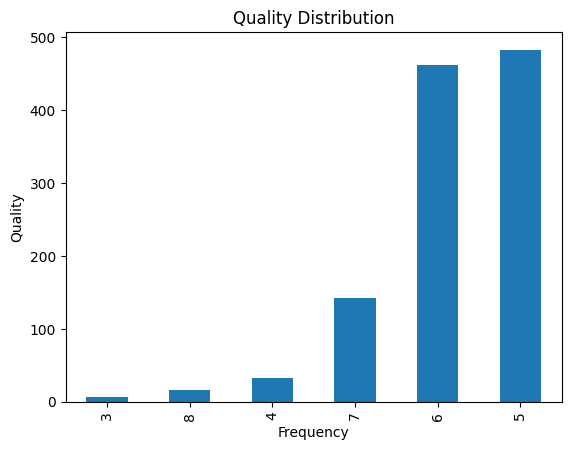

In [14]:
# Check the distribution of target variable
df['quality'].value_counts().sort_values(ascending=True).plot(kind='bar')
plt.title('Quality Distribution')
plt.xlabel('Frequency')
plt.ylabel('Quality')
plt.show()

# Clearly the data is imbalanced so we need to balance it before applying machine learning algorithms.

In [15]:
# Drop the 'Id' column as it is not relevant for classification tasks.
df.drop(columns=['Id'],inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [17]:
# Percentage of missing values in each column
df.isnull().mean()*100

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [18]:
# Splitting Data into Features and Target Variable
from sklearn.model_selection import train_test_split

X = df.drop('quality',axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (914, 11)
Test set size: (229, 11)


In [22]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Calculate the mutual information for each feature with the target variable
mi = mutual_info_classif(X_train, y_train, random_state=45)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'Mutual Information(Bits)': mi})

print(mi_df)

                 Feature  Mutual Information(Bits)
0          fixed acidity                  0.032766
1       volatile acidity                  0.131066
2            citric acid                  0.095590
3         residual sugar                  0.017480
4              chlorides                  0.026493
5    free sulfur dioxide                  0.034792
6   total sulfur dioxide                  0.116177
7                density                  0.042622
8                     pH                  0.019350
9              sulphates                  0.100489
10               alcohol                  0.172916


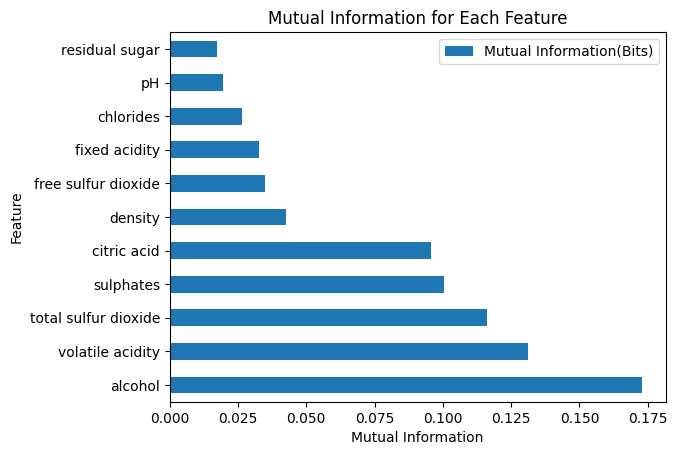

In [40]:
# Plotting the mutual information for each feature
mi_df.sort_values(by='Mutual Information(Bits)',ascending=False).plot.barh(
    x="Feature",
    y="Mutual Information(Bits)"
)
plt.title('Mutual Information for Each Feature')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.show()


## Analysis of the Mutual Information Plot

Mutual Information measures how much knowing a feature reduces uncertainty about the wine quality. A higher score indicates a stronger statistical relationship, while a lower score indicates a weaker relationship.

### Important Interpretation

Mutual Information can detect both linear and nonlinear relationships between a feature and the target. However, MI does **not prove causation**, and it does not indicate whether a feature increases or decreases quality. It only measures the strength of the dependency between the feature and the target.

For example, the high MI score of `alcohol` means that alcohol content contains useful information for predicting wine quality. It does not mean that increasing alcohol content will necessarily cause the quality score to increase.

Finally, **MI scores should be used as a guide for feature selection, not as the only measure of feature importance**. The selected features should also be evaluated using a machine learning model and appropriate performance metrics.

In [24]:
# Selecting top k best features

k = 5 # Number of top features to select
selector = SelectKBest(mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print("Train set size after feature selection:", X_train_selected.shape)
print("Test set size after feature selection:", X_test_selected.shape)

Train set size after feature selection: (914, 5)
Test set size after feature selection: (229, 5)


In [25]:
getattr(selector, 'scores_')


array([0.01456314, 0.11913835, 0.07342737, 0.00532399, 0.05167532,
       0.04643799, 0.08994516, 0.0468163 , 0.01930538, 0.08743661,
       0.18908982])

In [26]:
X_train_selected = pd.DataFrame(X_train_selected, columns=X_train.columns[selector.get_support()] )
X_test_selected = pd.DataFrame(X_test_selected, columns=X_test.columns[selector.get_support()] )

X_train_selected.sample(5)

,volatile acidity,citric acid,total sulfur dioxide,sulphates,alcohol
712,0.695,0.13,20.0,0.54,10.1
301,0.695,0.00,56.0,0.67,9.2
91,0.590,0.00,58.0,0.65,9.3
129,0.570,0.01,27.0,0.84,12.5
646,0.550,0.35,66.0,0.56,9.2


## 2. Regression 

### `mutual_info_regression` (Regression Tasks)

The `mutual_info_regression` function measures the shared information between a set of features and a **continuous target variable** (e.g., house prices, temperature readings, or stock value). 

####  How It Works Under the Hood

When both the input features and the target variable are continuous numbers, the problem shifts entirely to **Differential Entropy** and double integrals. Calculating true integrals from data samples directly is incredibly difficult, so `mutual_info_regression` also leverages a non-parametric **\(k\)-NN distance estimator**.

1. It maps out the joint continuous space formed by plotting the feature against the continuous target.
2. For each data point, it computes the distance to its \(k\)-th nearest neighbor in the joint space.
3. It projects these neighborhood boundaries onto the individual feature and target dimensions.
4. By comparing the size of the joint neighborhood space against the individual spaces, it estimates the continuous mutual information score.



#### 📊 Value Range & Interpretation

* **`0.0`:** The feature shares absolutely no linear or non-linear relationship with the target variable.

* **Values Greater Than `0.0`:** Indicates the number of bits of information shared. Unlike standard correlation coefficients ($R$) which cap strictly at `1.0`, continuous mutual information **can exceed 1.0** if the feature and continuous target are tied together by a highly precise, low-noise functional relationship.


In [27]:
df = pd.read_csv("../DataSets/concrete.csv")
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
794,302.0,0.0,0.0,203.0,0.0,974.0,817.0,180,26.74
845,321.0,164.0,0.0,190.0,5.0,870.0,774.0,28,57.21
485,387.0,20.0,94.0,157.0,14.3,938.0,845.0,28,50.24
862,140.0,164.0,128.0,237.0,6.0,869.0,656.0,28,35.23
545,255.0,0.0,0.0,192.0,0.0,889.8,945.0,28,18.75


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [29]:
df.isnull().mean()*100

Cement                0.0
Blast Furnace Slag    0.0
Fly Ash               0.0
Water                 0.0
Superplasticizer      0.0
Coarse Aggregate      0.0
Fine Aggregate        0.0
Age                   0.0
Strength              0.0
dtype: float64

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop('Strength',axis=1)
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (824, 8)
Test set size: (206, 8)


In [31]:
from sklearn.feature_selection import mutual_info_regression

mutual_info = mutual_info_regression(X_train,y_train)
mutual_info_df = pd.DataFrame({'Feature':X_train.columns,'Mutual Information(Bits)':mutual_info})

mutual_info_df

,Feature,Mutual Information(Bits)
0,Cement,0.281979
1,Blast Furnace Slag,0.214220
2,Fly Ash,0.105497
3,Water,0.330070
4,Superplasticizer,0.191110
5,Coarse Aggregate,0.193658
6,Fine Aggregate,0.161398
7,Age,0.337365


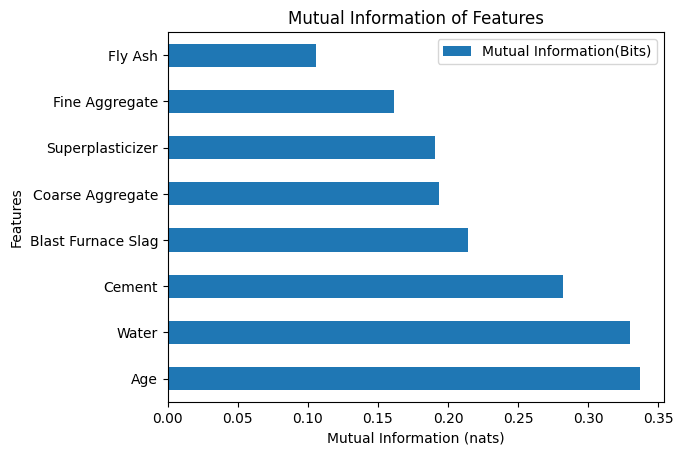

In [32]:
mutual_info_df.sort_values(by='Mutual Information(Bits)',ascending=False).plot.barh(
    x='Feature',
    y='Mutual Information(Bits)',
)
plt.title('Mutual Information of Features')
plt.ylabel('Features')
plt.xlabel('Mutual Information (nats)')
plt.show()

## Analysis of the Mutual Information Plot

A higher MI score means that the feature contains more information about concrete strength. A lower score means that the feature has a weaker statistical relationship with strength.

### Feature Selection Interpretation

Based on above plot, `Age`, `Water`, and `Cement` would be strong candidates for feature selection because they have the highest MI scores. The other features may still improve prediction when used together, even if their individual MI scores are lower.

### Important Interpretation

Mutual Information can detect both linear and nonlinear relationships between a feature and concrete strength. However, MI does **not prove causation**, and it does not indicate whether a feature increases or decreases strength. It only measures the strength of the dependency between the feature and the target.

For example, the high MI score of `Age` means that concrete age contains useful information for predicting strength. It does not, by itself, prove that increasing age directly causes the strength to increase in every situation.

> NOTE: MI scores should therefore be used as a guide for feature selection, not as the only measure of feature importance. The selected features should also be evaluated using a regression model and metrics such as $R^2$, MAE, and RMSE.

> **Note:** Scikit-learn's `mutual_info_regression` returns MI values in nats by default, not bits. Therefore, you need to convert the MI values from nats to bits using the formula below:
>
> $$MI_{\text{bits}} = \frac{MI_{\text{nats}}}{\ln(2)}$$

### 1. Select with K best feature


In [33]:
# Selecting K best feature
k=5
selector = SelectKBest(mutual_info_regression,k=k)

X_train_selected = selector.fit_transform(X_train,y_train)
X_test_selected = selector.transform(X_test)


In [34]:
getattr(selector,'scores_')

array([0.2829894 , 0.21246964, 0.10539857, 0.31917878, 0.19535196,
       0.20079097, 0.16234924, 0.33834923])

In [35]:
# Converting to pandas DataFrame
X_train_selected = pd.DataFrame(X_train_selected,columns=X_train.columns[selector.get_support()])
X_test_selected = pd.DataFrame(X_test_selected,columns=X_test.columns[selector.get_support()])

X_train_selected.sample(4)

,Cement,Blast Furnace Slag,Water,Coarse Aggregate,Age
327,212.5,0.0,159.3,1007.8,56.0
814,277.1,0.0,160.6,973.9,100.0
178,145.9,230.5,202.5,827.0,28.0
564,285.0,190.0,163.0,1031.0,28.0


### 2. Select with percentile


In [49]:
from sklearn.feature_selection import SelectPercentile

percentile=50
selector_per = SelectPercentile(mutual_info_regression, percentile=percentile)

X_train_per = selector_per.fit_transform(X_train,y_train)
X_test_per = selector_per.transform(X_test)



In [50]:
X_train_selected_per = pd.DataFrame(X_train_per,columns=X_train.columns[selector_per.get_support()])
X_test_selected_per = pd.DataFrame(X_test_per,columns=X_test.columns[selector_per.get_support()])

X_train_selected_per.sample(4)

,Cement,Blast Furnace Slag,Water,Age
809,393.0,0.0,192.0,90.0
677,491.0,26.0,210.0,7.0
341,297.2,0.0,174.8,14.0
32,173.5,50.1,164.8,56.0
